# Sychel Customer Churn Application

# Introduction

### Business problem
Customer churn is a major challenge for telecommnication companies as acquiring new customers is more costly than retaining existing ones.
The customer retention team's goal is to proactively identify customers at high risk of churning and try to help before they leave.

### Objective
The objective of this project is to build a classification model that predicts whether a customer will churn based on their usage patterns, service plans and account information

## Data Understanding

The dataset contains customer-level information including call usage statistics, service plans, voicemail usage, and international calling behavior.

### Key Observations
- The dataset includes both numerical and categorical features
- The target variable is imbalanced, with fewer churned customers
- Usage-related features appear likely to influence churn behavior


In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Loading the Dataset

In [160]:
# load the dataset
df = pd.read_csv("data/bigml_59c28831336c6604c800002a.csv")
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [161]:
df.tail()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False
3332,TN,74,415,400-4344,no,yes,25,234.4,113,39.85,...,82,22.60,241.4,77,10.86,13.7,4,3.70,0,False


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [163]:
df.shape

(3333, 21)

In [164]:
df.dtypes

state                      object
account length              int64
area code                   int64
phone number               object
international plan         object
voice mail plan            object
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                        bool
dtype: object

## Data Cleaning

Check for nulls and duuplicates, drop non-predictive columns

In [165]:
df.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [166]:
df.duplicated().sum()

0

In [167]:
df = df.drop(columns='phone number')

In [168]:
# Strip any whitespace from categorical columns and change type to category
df['international plan'] = df['international plan'].str.strip().str.lower().astype('category')
df['voice mail plan'] = df['voice mail plan'].str.strip().str.lower().astype('category')

df['area code'] = df['area code'].astype('category')

# Verify no duplicates
df.drop_duplicates(inplace=True)
print(f"Cleaned Data Shape: {df.shape}")

Cleaned Data Shape: (3333, 20)


## Explaratory Data Analysis

In [169]:
df['churn'].value_counts(normalize=True)


False    0.855086
True     0.144914
Name: churn, dtype: float64

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   state                   3333 non-null   object  
 1   account length          3333 non-null   int64   
 2   area code               3333 non-null   category
 3   international plan      3333 non-null   category
 4   voice mail plan         3333 non-null   category
 5   number vmail messages   3333 non-null   int64   
 6   total day minutes       3333 non-null   float64 
 7   total day calls         3333 non-null   int64   
 8   total day charge        3333 non-null   float64 
 9   total eve minutes       3333 non-null   float64 
 10  total eve calls         3333 non-null   int64   
 11  total eve charge        3333 non-null   float64 
 12  total night minutes     3333 non-null   float64 
 13  total night calls       3333 non-null   int64   
 14  total night charge      

In [171]:
df.describe()

,account length,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


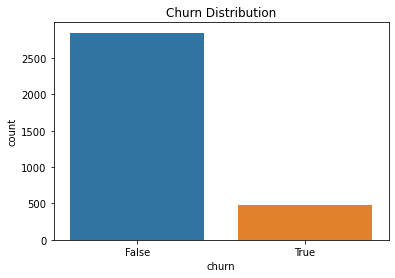

In [172]:
# Distribution of target
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.title('Churn Distribution')
plt.show()

The target is highly imbalanced. Most observations belong to one class, while the minority class is underrepresented. Because of this, accuracy alone would be misleading, so we focused on recall to ensure the minority class was correctly identified.

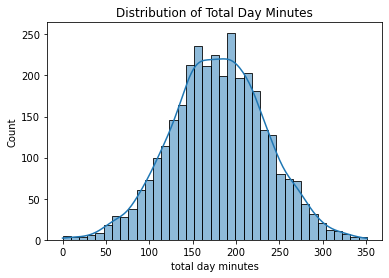

In [173]:
plt.figure(figsize=(6, 4))
sns.histplot(df['total day minutes'], kde=True)
plt.title('Distribution of Total Day Minutes')
plt.show()


The histogram shows the distribution of total day minutes. Most customers are within moderate usage, while few customers are the extremes.

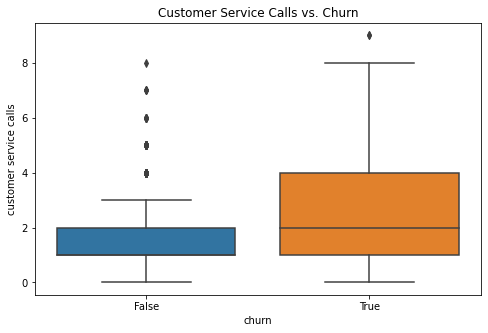

In [174]:
# customer service calls vs churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='churn', y='customer service calls', data=df)
plt.title('Customer Service Calls vs. Churn')
plt.show()

The boxplot shows the number of customer service calls between churned and non-churned customers. Customers who churned have a higher number of service calls while those who did not churn made fewer service calls.

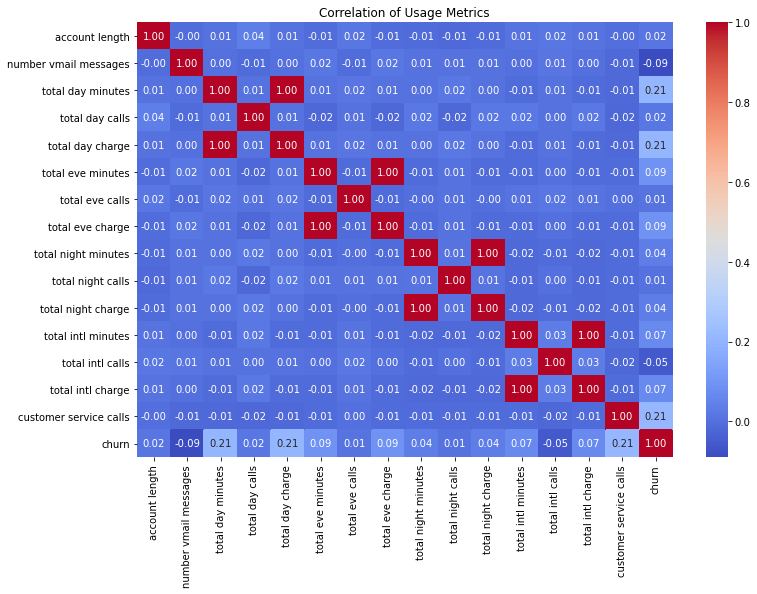

In [175]:
#Correlation Heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation of Usage Metrics')
plt.show()

Charges correlate strongly with minutes, therefore charge columns need to be dropped to avoid redundancy.  

## Feature Engineering

Correlation revealed redudancy between call charges and call minutes. To reduce it and improve the stability of the model, charge related features were removed.

In [176]:
# dropping highely correlated charge columns
charge_cols = [
    'total day charge',
    'total eve charge',
    'total night charge',
    'total intl charge'
]

df = df.drop(columns=charge_cols)

In [177]:
# confirming the columns were dropped
df.columns

Index(['state', 'account length', 'area code', 'international plan',
       'voice mail plan', 'number vmail messages', 'total day minutes',
       'total day calls', 'total eve minutes', 'total eve calls',
       'total night minutes', 'total night calls', 'total intl minutes',
       'total intl calls', 'customer service calls', 'churn'],
      dtype='object')

Interaction features were engineered to capture normalized customer behavior. Average call duration features represent usage intensity, while total call volume and service call rate provide insight into overall activity and customer support engagement.

In [178]:
# Average call duration 
df['avg_day_call'] = df['total day minutes'] / df['total day calls'].replace(0, 1)
df['avg_eve_call'] = df['total eve minutes'] / df['total eve calls'].replace(0, 1)
df['avg_night_call'] = df['total night minutes'] / df['total night calls'].replace(0, 1)
df['avg_intl_call'] = df['total intl minutes'] / df['total intl calls'].replace(0, 1)

# Ensures 0 averages where no calls have been made
for period in ['day', 'eve', 'night', 'intl']:
    df.loc[df[f'total {period} calls'] == 0, f'avg_{period}_call'] = 0


Summarizes activity volume and adjusts service engagement by customer's overall activity

In [179]:
# sum of all calls
df['total_calls'] = (
    df['total day calls'] +
    df['total eve calls'] +
    df['total night calls'] +
    df['total intl calls']
)


In [180]:
df['service_call_rate'] = (
    df['customer service calls'] / (df['total_calls'] + 1)
)


In [181]:
df[['avg_day_call', 'avg_eve_call', 'avg_night_call', 'avg_intl_call']].describe()


,avg_day_call,avg_eve_call,avg_night_call,avg_intl_call
count,3333.000000,3333.000000,3333.000000,3333.000000
mean,1.871421,2.103123,2.091748,3.095576
std,0.732772,0.776384,0.709582,2.266207
min,0.000000,0.000000,0.227451,0.000000
25%,1.379592,1.615625,1.608397,1.671429
50%,1.790517,1.985246,2.005607,2.450000
75%,2.261765,2.486842,2.461538,3.800000
max,7.223333,15.608333,7.124242,18.200000


Reduces skew and stabilizes the effect of heavy users

In [182]:
usage_cols = [
    'total day minutes',
    'total eve minutes',
    'total night minutes',
    'total intl minutes'
]

for col in usage_cols:
    df[f'log_{col}'] = np.log1p(df[col])

## Pre-processing

In [207]:
# Separating features and targt
X = df.drop(columns='churn')
y = df['churn'].astype(int)

In [184]:
# Encoding binary categorica variables
X['international plan'] = (X['international plan'].astype(str).str.strip().str.lower().map({'yes':1, 'no': 0}).fillna(0))
X['voice mail plan'] = (X['voice mail plan'].astype(str).str.strip().str.lower().map({'yes':1, 'no':0}).fillna(0))

In [185]:
# Drop state 
X = X.drop(columns=['state'])

In [186]:
# One-hot encoding
X = pd.get_dummies(X, columns=['area code'], drop_first=True, dtype=int)

In [187]:
X.isnull().sum()

account length             0
international plan         0
voice mail plan            0
number vmail messages      0
total day minutes          0
total day calls            0
total eve minutes          0
total eve calls            0
total night minutes        0
total night calls          0
total intl minutes         0
total intl calls           0
customer service calls     0
avg_day_call               0
avg_eve_call               0
avg_night_call             0
avg_intl_call              0
total_calls                0
service_call_rate          0
log_total day minutes      0
log_total eve minutes      0
log_total night minutes    0
log_total intl minutes     0
area code_415              0
area code_510              0
dtype: int64

In [188]:
X.isna().sum()

account length             0
international plan         0
voice mail plan            0
number vmail messages      0
total day minutes          0
total day calls            0
total eve minutes          0
total eve calls            0
total night minutes        0
total night calls          0
total intl minutes         0
total intl calls           0
customer service calls     0
avg_day_call               0
avg_eve_call               0
avg_night_call             0
avg_intl_call              0
total_calls                0
service_call_rate          0
log_total day minutes      0
log_total eve minutes      0
log_total night minutes    0
log_total intl minutes     0
area code_415              0
area code_510              0
dtype: int64

In [189]:
X = X.fillna(0)

In [190]:
X.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,...,avg_night_call,avg_intl_call,total_calls,service_call_rate,log_total day minutes,log_total eve minutes,log_total night minutes,log_total intl minutes,area code_415,area code_510
0,128,0,1,25,265.1,110,197.4,99,244.7,91,...,2.689011,3.333333,303,0.003289,5.583872,5.290285,5.504111,2.397895,1,0
1,107,0,1,26,161.6,123,195.5,103,254.4,103,...,2.469903,4.566667,332,0.003003,5.091293,5.280662,5.542831,2.687847,1,0
2,137,0,0,0,243.4,114,121.2,110,162.6,104,...,1.563462,2.440000,333,0.000000,5.498806,4.805659,5.097424,2.580217,1,0
3,84,1,0,0,299.4,71,61.9,88,196.9,89,...,2.212360,0.942857,255,0.007812,5.705115,4.141546,5.287762,2.028148,0,0
4,75,1,0,0,166.7,113,148.3,122,186.9,121,...,1.544628,3.366667,359,0.008333,5.122177,5.005958,5.235910,2.406945,1,0


### Train-test split

The dataset was split into training and testing using stratify to ensure reproductivity and preserving clas distribution.

In [191]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(2666, 25) (667, 25)


### Scaling

Scaling was applied to the logistic regression model. Tree based models were trained on unscaled data.

In [192]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##  Model Selection and Training

Logistic regression and decision tree classification models were trained to capture nonlinear relationships. Hyperparameter tuning was done uding GridSearchCV with recall for optimization to prioritize identification of churned customers.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


# Logistic Regression (Baseline)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Decision Tree 
dtree = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dtree.fit(X_train, y_train)
y_pred_tree = dtree.predict(X_test)

param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}
# tuned decision tree
dtree_tuned = GridSearchCV(
    DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

dtree_tuned.fit(X_train, y_train)
best_dtree = dtree_tuned.best_estimator_



## Model evaluation

Interpret model, and look into drivers like customer service calls and usage intensity

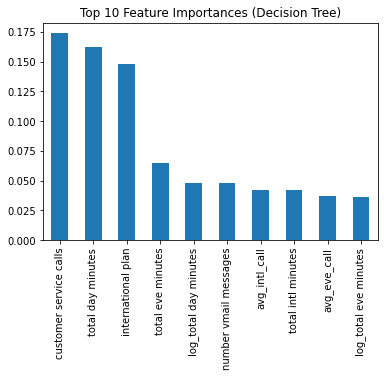

In [194]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    dtree.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.show()


Models were evaluated on test data using recall, ROC-AUC, and PR-AUC.
Perfomance was compared across models to identify the most effective approach.

In [195]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dtree,
    "Tuned Decision Tree": best_dtree
}

results = []

for name, model in models.items():
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.764618,0.348485,0.711340,0.467797,0.819208
1,Decision Tree,0.875562,0.562500,0.649485,0.602871,0.781760
2,Tuned Decision Tree,0.887556,0.587302,0.762887,0.663677,0.831109


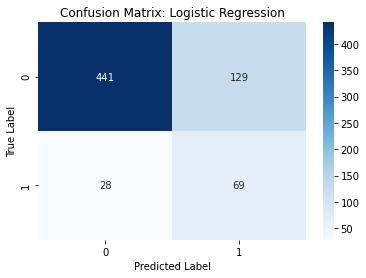

In [196]:

# Model Evaluation: Logistic Regression


from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on scaled test data
y_pred_log = log_reg.predict(X_test_scaled)

# Compute confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [197]:

# Logistic Regression


from sklearn.metrics import classification_report

y_pred_log = log_reg.predict(X_test_scaled)

print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred_log))


Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.77      0.85       570
           1       0.35      0.71      0.47        97

    accuracy                           0.76       667
   macro avg       0.64      0.74      0.66       667
weighted avg       0.85      0.76      0.79       667



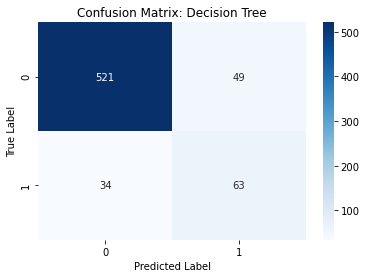

In [198]:

# Model Evaluation: Decision Tree


# Predict on unscaled test data
y_pred_tree = dtree.predict(X_test)

# Compute confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [199]:

#  Decision Tree


y_pred_tree = dtree.predict(X_test)

print("Classification Report: Decision Tree")
print(classification_report(y_test, y_pred_tree))


Classification Report: Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       570
           1       0.56      0.65      0.60        97

    accuracy                           0.88       667
   macro avg       0.75      0.78      0.76       667
weighted avg       0.88      0.88      0.88       667



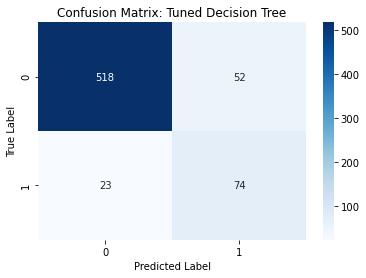

In [200]:

# Model Evaluation: Tuned Decision Tree


# Predict on unscaled test data
y_pred_best = dtree_tuned.predict(X_test)

# Compute confusion matrix
cm_best = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Tuned Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [201]:

#  Tuned Decision Tree


y_pred_best = dtree_tuned.predict(X_test)

print("Classification Report: Tuned Decision Tree")
print(classification_report(y_test, y_pred_best))


Classification Report: Tuned Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       570
           1       0.59      0.76      0.66        97

    accuracy                           0.89       667
   macro avg       0.77      0.84      0.80       667
weighted avg       0.90      0.89      0.89       667



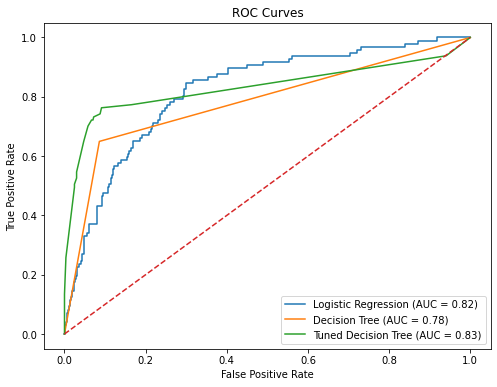

In [202]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    if name == "Logistic Regression":
        y_scores = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_scores = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")


plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


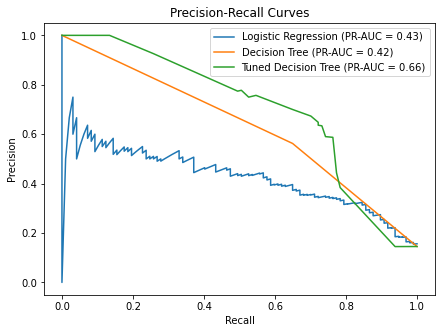

In [203]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 5))

for name, model in models.items():
    if name == "Logistic Regression":
        y_scores = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_scores = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = average_precision_score(y_test, y_scores)

    plt.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()


Show that tuned Decision Tree performs best on recall and PR-AUC

In [204]:
from sklearn.metrics import recall_score, roc_auc_score, average_precision_score

results = []


In [205]:
for name, model in models.items():

   
    if name == "Logistic Regression":
        X_eval = X_test_scaled
    else:
        X_eval = X_test

    # Predictions
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    # Metrics
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Recall": recall,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })


In [206]:
results_df = pd.DataFrame(results)
results_df


,Model,Recall,ROC-AUC,PR-AUC
0,Logistic Regression,0.711340,0.819208,0.429596
1,Decision Tree,0.649485,0.781760,0.416310
2,Tuned Decision Tree,0.762887,0.831109,0.656167


## Final Model

- Selected Model: Tuned Decision Tree (class_weight='balanced'), tuned via recall-focused GridSearchCV.
- Why:
  - Highest recall and superior PR-AUC among candidates, meaning better identification of churners with fewer unnecessary alerts than the baseline tree or logistic regression.
  - Interpretability: Feature importances indicate operational drivers (e.g., customer service calls and usage intensity).

## Insights

- Strong churn indicators:
  - High customer service calls and higher service_call_rate suggest dissatisfaction and are consistently associated with churn.
  - Usage intensity features (averages and totals) help capture behavioral patterns relevant to churn risk.

## Recommendations

- Decision policy: Use the tuned Decision Tree with a recall-oriented threshold to flag high-risk customers.
- Operational playbook:
  - Proactively contact flagged customers with targeted retention offers or plan reviews.
  - Pay extra attention to customers with high service_call_rate and specific usage patterns.
- KPI monitoring:
  - Track recall and precision of churn flags, and measure program ROI (savings vs outreach costs).
  - Adjust thresholds to balance cost and coverage.
- Maintenance:
  - Retrain and recalibrate periodically (e.g., quarterly) to address data drift.
  - Extend features (e.g., ticket severity, recent plan changes, tenure trends) to further improve recall and PR-AUC.

## Limitations

- Segment performance:
  - Customers with very low usage may be harder to classify; consider segment-specific thresholds.
- Data drift:
  - Behavioral and seasonal changes may alter relationships; monitor and retrain regularly.
- Feature scope:
  - No direct measures of satisfaction (NPS, survey ratings) were included; adding them could improve performance.
- Trade-offs:
  - Higher recall can increase false positives and outreach volume; precision should be monitored for operational efficiency.




## Conclusion

This project delivers a recall-first churn prediction model suitable for proactive retention. The tuned Decision Tree provides the best recall and PR-AUC among candidates while remaining interpretable for business stakeholders. With threshold tuning, ongoing monitoring, and periodic retraining, the model can be deployed to support timely and cost-effective customer retention strategies.
